In [58]:
import pandas as pd

In [59]:
df = pd.read_csv('crypto_combine.csv')

In [60]:
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [61]:
df.shape

(7899, 6)

In [62]:
df.isnull().sum()

Crypto    0
Date      0
Open      0
High      0
Low       0
Close     0
dtype: int64

In [63]:
df = df.drop_duplicates()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [65]:
df.describe()

,Open,High,Low,Close
count,7899.000000,7899.000000,7899.000000,7899.000000
mean,5479.620176,5623.947143,5324.149024,5480.870398
std,12010.579332,12325.039614,11665.236339,12011.567525
min,0.140000,0.150000,0.120000,0.140000
25%,12.720000,13.410000,12.405000,12.680000
50%,170.910000,176.240000,163.320000,170.890000
75%,3879.000000,3962.000000,3757.000000,3878.935000
max,67802.000000,68925.000000,66112.000000,67802.000000


In [66]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Extract year, month, day, day of the week, quarter, and season as new features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Apply the function to create a new 'Season' column
df['Season'] = df['Month'].apply(get_season)

/var/folders/s1/87_2c35s4yl8bmjgyqv0txh00000gn/T/ipykernel_19242/3195280480.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [68]:
df["Target"] = df["Close"].shift(-1)

In [69]:
df.head()

,Crypto,Date,Open,High,Low,Close,Year,Month,Day,DayOfWeek,Quarter,Season,Target
0,XRP,2018-01-01,1.99,2.10,1.82,2.10,2018,1,1,0,1,Winter,225.63
1,LTC,2018-01-01,230.32,237.77,217.87,225.63,2018,1,1,0,1,Winter,757.01
2,ETH,2018-01-01,744.39,772.98,725.10,757.01,2018,1,1,0,1,Winter,13535.00
3,BTC,2018-01-01,13996.00,14035.00,12860.00,13535.00,2018,1,1,0,1,Winter,14770.00
4,BTC,2018-01-02,13535.00,15217.00,12956.00,14770.00,2018,1,2,1,1,Winter,2.21


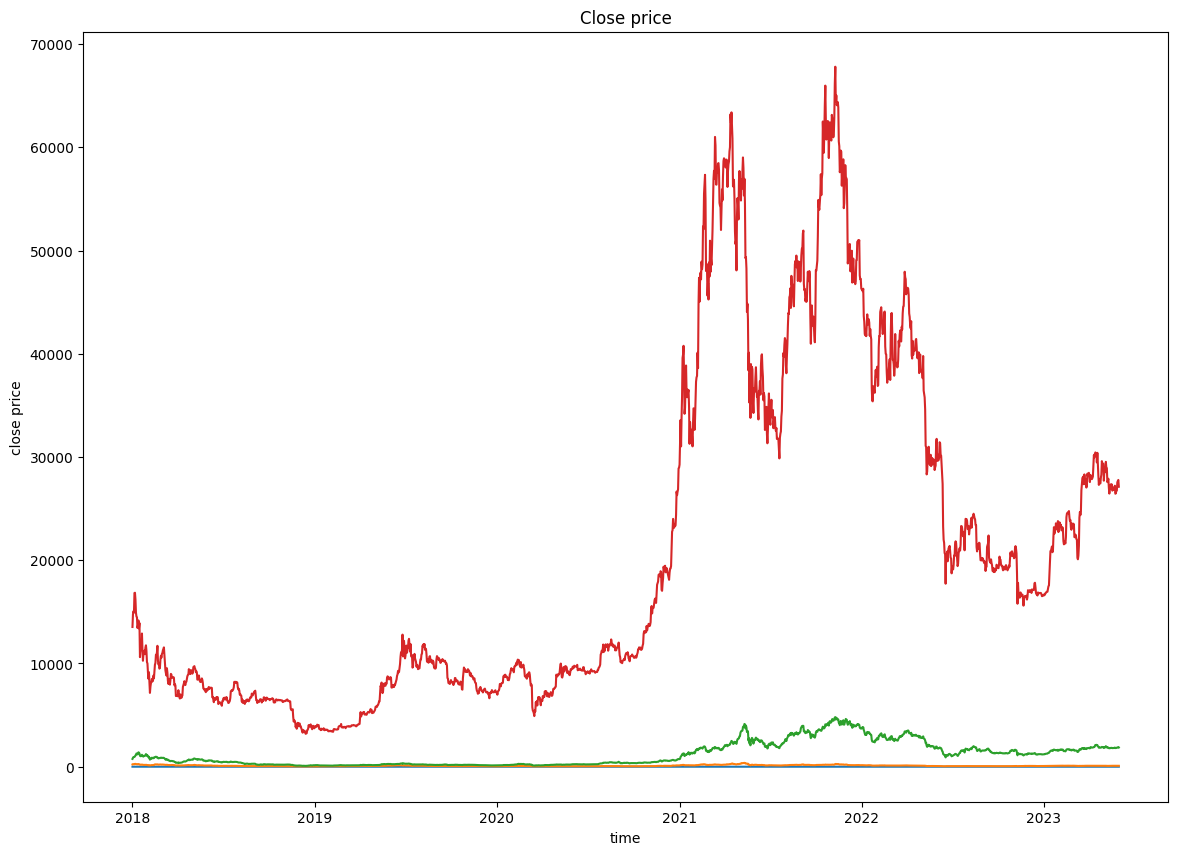

In [70]:

import matplotlib.pyplot as plt
crypto_list = df['Crypto'].unique()
plt.figure(figsize=(14,10))

for crypto in crypto_list:
    crypto_df = df[df['Crypto'] == crypto]
    plt.plot(crypto_df['Date'], crypto_df['Close'], label=crypto)

plt.title('Close price')
plt.xlabel('time')
plt.ylabel('close price')
plt.show()

In [71]:
df["Daily_Return"] = df["Close"].pct_change()

df["Price_Range"] = df["High"] - df["Low"]

df["Open_Close_Change"] = df["Close"] - df["Open"]

df["High_Low_Percentage"] = (
    (df["High"] - df["Low"]) / df["Close"]
)

df["Close_Lag_1"] = df["Close"].shift(1)
df["Close_Lag_2"] = df["Close"].shift(2)
df["Close_Lag_3"] = df["Close"].shift(3)

df["Rolling_Mean_7"] = df["Close"].rolling(7).mean()
df["Rolling_Mean_14"] = df["Close"].rolling(14).mean()
df["Rolling_Mean_30"] = df["Close"].rolling(30).mean()

df["Rolling_Std_7"] = df["Close"].rolling(7).std()
df["Rolling_Std_14"] = df["Close"].rolling(14).std()

In [73]:
df.describe()

,Date,Open,High,Low,Close,Year,Month,Day,DayOfWeek,Quarter,...,Open_Close_Change,High_Low_Percentage,Close_Lag_1,Close_Lag_2,Close_Lag_3,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_30,Rolling_Std_7,Rolling_Std_14
count,7899,7899.000000,7899.000000,7899.000000,7899.000000,7899.000000,7899.000000,7899.000000,7899.000000,7899.000000,...,7899.000000,7899.000000,7898.000000,7897.000000,7896.000000,7893.000000,7886.000000,7870.000000,7893.000000,7886.000000
mean,2020-09-15 02:46:26.479300864,5479.620176,5623.947143,5324.149024,5480.870398,2020.229396,6.255855,15.728067,2.996075,2.424484,...,1.250222,0.068930,5481.553005,5482.010859,5482.705071,5481.971600,5481.549992,5480.799127,9249.208774,9056.084808
min,2018-01-01 00:00:00,0.140000,0.150000,0.120000,0.140000,2018.000000,1.000000,1.000000,0.000000,1.000000,...,-6903.000000,0.000000,0.140000,0.140000,0.140000,486.234286,534.422857,731.422333,623.310530,1241.475452
25%,2019-05-10 00:00:00,12.720000,13.410000,12.405000,12.680000,2019.000000,3.000000,8.000000,1.000000,1.000000,...,-3.485000,0.035735,7.730000,2.780000,17.630000,1935.732857,2041.388929,2066.923167,3511.538732,3473.447837
50%,2020-09-15 00:00:00,170.910000,176.240000,163.320000,170.890000,2020.000000,6.000000,16.000000,3.000000,2.000000,...,0.000000,0.054434,170.925000,170.890000,170.925000,3330.515714,3383.310714,3191.633833,5581.850838,5318.275603
75%,2022-01-22 12:00:00,3879.000000,3962.000000,3757.000000,3878.935000,2022.000000,9.000000,23.000000,5.000000,3.000000,...,4.855000,0.084370,3879.402500,3879.870000,3879.902500,7811.632857,8329.614464,8409.103000,13943.969192,13738.521363
max,2023-05-31 00:00:00,67802.000000,68925.000000,66112.000000,67802.000000,2023.000000,12.000000,31.000000,6.000000,4.000000,...,6187.000000,0.974359,67802.000000,67802.000000,67802.000000,28900.065714,24096.595714,19615.310333,34511.130294,31329.751047
std,NaN,12010.579332,12325.039614,11665.236339,12011.567525,1.575175,3.462528,8.792290,2.000787,1.120704,...,488.856182,0.057078,12012.174796,12012.866501,12013.468850,4826.464566,4485.390664,4389.503057,7460.607174,7197.134226


In [74]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",

    "Daily_Return",
    "Price_Range",
    "Open_Close_Change",
    "High_Low_Percentage",

    "Close_Lag_1",
    "Close_Lag_2",
    "Close_Lag_3",

    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30",

    "Rolling_Std_7",
    "Rolling_Std_14"
]

In [82]:
df.isnull().sum()

Crypto                  0
Date                    0
Open                    0
High                    0
Low                     0
Close                   0
Year                    0
Month                   0
Day                     0
DayOfWeek               0
Quarter                 0
Season                  0
Target                  1
Daily_Return            1
Price_Range             0
Open_Close_Change       0
High_Low_Percentage     0
Close_Lag_1             1
Close_Lag_2             2
Close_Lag_3             3
Rolling_Mean_7          6
Rolling_Mean_14        13
Rolling_Mean_30        29
Rolling_Std_7           6
Rolling_Std_14         13
dtype: int64

In [83]:
df = df.dropna().reset_index(drop=True)

In [84]:
X = df[features]
y = df["Target"]

In [85]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [86]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("Train end:", df.iloc[split - 1]["Date"])
print("Test start:", df.iloc[split]["Date"])

Training: (6295, 21)
Testing : (1574, 21)
Train end: 2022-05-02 00:00:00
Test start: 2022-05-03 00:00:00


In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)


mae = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2 = r2_score(y_train, y_pred_train)

print("Linear Regression train")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression test")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression train
MAE : 6095.366993734882
RMSE: 10048.68532684173
R2  : 0.35248081729171865
Linear Regression test
MAE : 6824.118844077408
RMSE: 8770.365969935125
R2  : 0.22279625423394578


In [89]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_train = rf.predict(X_train)


mae = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2 = r2_score(y_train, y_pred_train)

print("Linear Regression train")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("Linear Regression test")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Linear Regression train
MAE : 6298.769080219497
RMSE: 10617.78851893266
R2  : 0.2770599451577853
Linear Regression test
MAE : 10765.267857959605
RMSE: 11439.965986317107
R2  : -0.32235761176001


In [100]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

rf2 = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 5, 7],
}

grid = GridSearchCV(
    estimator=rf2,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
y_pred_train = grid.predict(X_train)
print("Best Parameters:")
print(grid.best_params_)

print("Best CV RMSE:")
print(-grid.best_score_)

print(mean_absolute_error(y_train, y_pred_train))
print(np.sqrt(mean_squared_error(y_train, y_pred_train)))
print(r2_score(y_train, y_pred_train))

print('test ')
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))
print(r2_score(y_test, y_pred))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters:
{'max_depth': 5, 'n_estimators': 200}
Best CV RMSE:
9941.141238448447
5673.585031816814
9719.41869340678
0.39422028311276114
test 
10385.915750977383
10968.531629142468
-0.21561608189688553


In [91]:
from xgboost import XGBRFRegressor


xg = XGBRFRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
xg.fit(X_train, y_train)
y_pred = xg.predict(X_test)
y_pred_train = xg.predict(X_train)


print(mean_absolute_error(y_train, y_pred_train))
print(np.sqrt(mean_squared_error(y_train, y_pred_train)))
print(r2_score(y_train, y_pred_train))

print('test ')
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))
print(r2_score(y_test, y_pred))

6343.36071061909
10643.346564546962
0.27357538285910177
test 
13175.886512846697
14169.770737257524
-1.0287339647165044
